# Garbage Classification Tiny CNN Int8 Model (OpenMV-friendly)

This notebook is the **generic** part of the pipeline:
- Download or load a dataset
- Train a tiny grayscale CNN classifier (NPU-friendly ops)
- Export a fully-integer **int8** `.tflite`
- Sanity-check the exported model on desktop with `tf.lite.Interpreter`

You can then choose an accelerator-specific notebook:
- `CustomObjects_OpenMV_AE3_EthosU55.ipynb` (Vela / Ethos-U55)
- `CustomObjects_OpenMV_N6_NeuralART.ipynb` (ST Edge AI / Neural-ART)


In [1]:
import os
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


## 1) Dataset

Two options:

### Option A: local folder dataset (recommended for your own custom objects)
```
data/
  train/
    mug/
    keys/
    remote/
  val/
    mug/
    keys/
    remote/
```

### Option B: KaggleHub download (good for a quick public dataset)
Example:
```
import kagglehub
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
```

For Option B we do a stratified train/val split on the fly.


In [2]:
USE_KAGGLEHUB = True
KAGGLE_DATASET = "asdasdasasdas/garbage-classification"
FORCE_CLASS_ROOT = None  # set to a path string if auto-detection picks the wrong folder

DATA_DIR = Path('data')
IMG_SZ = 96
BATCH = 64
VAL_FRAC = 0.2

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}


def _has_images(p: Path) -> bool:
    for f in p.iterdir():
        if f.is_file() and f.suffix.lower() in IMG_EXTS:
            return True
    return False


def find_class_root(root: Path, max_depth: int = 6) -> Path:
    """Find a directory whose immediate subfolders look like class folders."""
    root = root.resolve()
    best = None
    best_score = (-1, -1)

    def depth(p: Path) -> int:
        try:
            return len(p.relative_to(root).parts)
        except Exception:
            return 999

    dirs = [root]
    for p in root.rglob('*'):
        if p.is_dir() and depth(p) <= max_depth:
            dirs.append(p)

    for d in dirs:
        subdirs = [s for s in d.iterdir() if s.is_dir()]
        if len(subdirs) < 2:
            continue
        class_dirs = [s for s in subdirs if _has_images(s)]
        if len(class_dirs) < 2:
            continue

        img_count = 0
        for c in class_dirs:
            img_count += sum(1 for f in c.iterdir() if f.is_file() and f.suffix.lower() in IMG_EXTS)
        score = (len(class_dirs), img_count)
        if score > best_score:
            best_score = score
            best = d

    if best is None:
        raise RuntimeError(f"Could not find class folders under: {root}")
    return best


def index_from_class_root(class_root: Path):
    class_dirs = [d for d in class_root.iterdir() if d.is_dir() and _has_images(d)]
    class_names = sorted([d.name for d in class_dirs])
    name_to_id = {n: i for i, n in enumerate(class_names)}

    items = []
    for cname in class_names:
        cdir = class_root / cname
        for p in sorted(cdir.iterdir()):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                items.append((str(p), name_to_id[cname]))
    return items, class_names


def split_items(items, val_frac=0.2):
    from collections import defaultdict

    by_cls = defaultdict(list)
    for p, y in items:
        by_cls[int(y)].append(p)

    train, val = [], []
    rng = np.random.default_rng(0)
    for y, paths in by_cls.items():
        paths = list(paths)
        rng.shuffle(paths)
        n_val = int(len(paths) * val_frac)
        val_paths = paths[:n_val]
        train_paths = paths[n_val:]
        train.extend([(p, y) for p in train_paths])
        val.extend([(p, y) for p in val_paths])

    rng.shuffle(train)
    rng.shuffle(val)
    return train, val


def load_image_label(path, y):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SZ, IMG_SZ)
    img = tf.cast(tf.clip_by_value(img, 0, 255), tf.float32) / 255.0
    return img, tf.cast(y, tf.int32)


def ds_from_items(items, shuffle=False):
    paths = [p for p, _ in items]
    labels = [int(y) for _, y in items]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(4096, len(paths)), seed=0)
    ds = ds.map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds


train_dir = DATA_DIR / 'train'
val_dir = DATA_DIR / 'val'

if (not USE_KAGGLEHUB) and train_dir.exists() and val_dir.exists():
    print('Using folder dataset:', train_dir, val_dir)
    train_ds = tf.keras.utils.image_dataset_from_directory(
        str(train_dir),
        labels='inferred',
        label_mode='int',
        color_mode='grayscale',
        image_size=(IMG_SZ, IMG_SZ),
        batch_size=BATCH,
        shuffle=True,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        str(val_dir),
        labels='inferred',
        label_mode='int',
        color_mode='grayscale',
        image_size=(IMG_SZ, IMG_SZ),
        batch_size=BATCH,
        shuffle=False,
    )
    class_names = train_ds.class_names
    train_ds = train_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
else:
    import kagglehub
    path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    print('KaggleHub dataset path:', path)

    class_root = Path(FORCE_CLASS_ROOT) if FORCE_CLASS_ROOT else find_class_root(path)
    print('Class root:', class_root)

    items, class_names = index_from_class_root(class_root)
    train_items, val_items = split_items(items, val_frac=VAL_FRAC)
    print('Train images:', len(train_items), 'Val images:', len(val_items))
    print('Classes:', class_names)

    train_ds = ds_from_items(train_items, shuffle=True)
    val_ds = ds_from_items(val_items, shuffle=False)


NUM_CLASSES = len(class_names)
print('NUM_CLASSES:', NUM_CLASSES)


Using Colab cache for faster access to the 'garbage-classification' dataset.
KaggleHub dataset path: /kaggle/input/garbage-classification
Class root: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
Train images: 2024 Val images: 503
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
NUM_CLASSES: 6


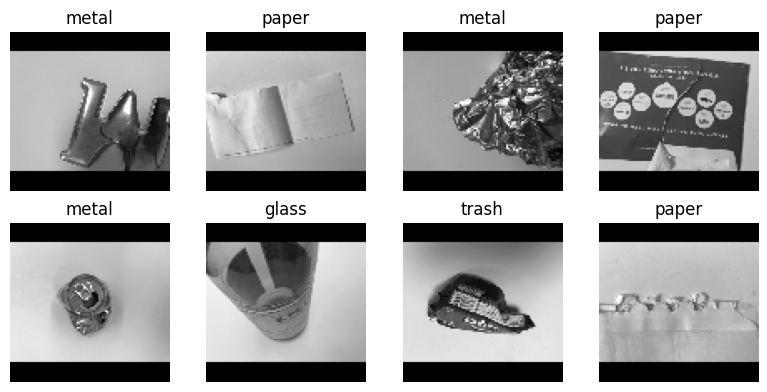

In [3]:
# Visualize a small batch
x, y = next(iter(train_ds))
plt.figure(figsize=(8, 4))
for i in range(min(8, x.shape[0])):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
    plt.title(class_names[int(y[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 2) Tiny, NPU-friendly CNN

Design constraints for edge/NPU:
- Prefer `Conv2D`, `DepthwiseConv2D`, `Add`, `ReLU`, `GlobalAveragePooling`
- Avoid big fully-connected layers
- Keep channels modest


In [4]:
from tensorflow.keras import layers, models

def build_tiny_ds_cnn(input_shape=(96, 96, 1), num_classes=3):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.DepthwiseConv2D(3, padding='same', activation='relu')(x)
    x = layers.Conv2D(24, 1, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.DepthwiseConv2D(3, padding='same', activation='relu')(x)
    x = layers.Conv2D(32, 1, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out, name='tiny_ds_cnn')


model = build_tiny_ds_cnn(input_shape=(IMG_SZ, IMG_SZ, 1), num_classes=NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()


Model: "tiny_ds_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 48, 48, 16)     │           160 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 24)     │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 24, 24, 24)     │           240 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 32)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,966 (7.68 KB)

 Trainable params: 1,966 (7.68 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(train_ds, validation_data=val_ds, epochs=100, verbose=2)


Epoch 1/100
32/32 - 25s - 783ms/step - accuracy: 0.2090 - loss: 1.7845 - val_accuracy: 0.2425 - val_loss: 1.7738
Epoch 2/100
32/32 - 2s - 67ms/step - accuracy: 0.2362 - loss: 1.7593 - val_accuracy: 0.2346 - val_loss: 1.7363
Epoch 3/100
32/32 - 2s - 67ms/step - accuracy: 0.2352 - loss: 1.7270 - val_accuracy: 0.2346 - val_loss: 1.7202
Epoch 4/100
32/32 - 3s - 94ms/step - accuracy: 0.2352 - loss: 1.7238 - val_accuracy: 0.2346 - val_loss: 1.7198
Epoch 5/100
32/32 - 2s - 70ms/step - accuracy: 0.2352 - loss: 1.7210 - val_accuracy: 0.2346 - val_loss: 1.7182
Epoch 6/100
32/32 - 4s - 128ms/step - accuracy: 0.2352 - loss: 1.7208 - val_accuracy: 0.2346 - val_loss: 1.7176
Epoch 7/100
32/32 - 3s - 98ms/step - accuracy: 0.2352 - loss: 1.7201 - val_accuracy: 0.2346 - val_loss: 1.7163
Epoch 8/100
32/32 - 3s - 92ms/step - accuracy: 0.2352 - loss: 1.7178 - val_accuracy: 0.2346 - val_loss: 1.7145
Epoch 9/100
32/32 - 2s - 73ms/step - accuracy: 0.2352 - loss: 1.7153 - val_accuracy: 0.2346 - val_loss: 1.709

## 3) Export fully-integer int8 `.tflite`

This produces:
- `models/custom_objects_int8.tflite`
- `models/custom_objects_labels.txt`


In [6]:
def representative_dataset(ds, num_batches=50):
    for x, _ in ds.take(num_batches):
        for i in range(x.shape[0]):
            yield [tf.expand_dims(x[i], 0)]


os.makedirs('models', exist_ok=True)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = lambda: representative_dataset(train_ds)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite = converter.convert()
tflite_path = os.path.join('models', 'custom_objects_int8.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite)

labels_path = os.path.join('models', 'custom_objects_labels.txt')
with open(labels_path, 'w', encoding='utf-8') as f:
    for n in class_names:
        f.write(n + '\n')

print('Wrote', tflite_path, 'bytes=', os.path.getsize(tflite_path))
print('Wrote', labels_path)
print('Class names:', class_names)


Saved artifact at '/tmp/tmpexqgvy25'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137172668700752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137172668702288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137172668703824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137172668704208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137172668705168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137172668702480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137172668704592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137172668704016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137172668705744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137172668704976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137172668706896:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Wrote models/custom_objects_int8.tflite bytes= 10448
Wrote models/custom_objects_labels.txt
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 4) Sanity-check the exported model

Before you deploy to hardware, verify that the exported `.tflite` runs and predicts something sensible.


In [7]:
import numpy as np

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]
print('Input:', inp)
print('Output:', out)

# Take one batch from val_ds
xb, yb = next(iter(val_ds))
x0 = xb[0:1].numpy()
y0 = int(yb[0].numpy())

# Quantize input
scale, zp = inp['quantization']
xi = np.round(x0 / scale + zp).astype(np.int8)

interpreter.set_tensor(inp['index'], xi)
interpreter.invoke()
yo = interpreter.get_tensor(out['index'])[0]

# Dequantize output to view it as floats
oscale, ozp = out['quantization']
probs = (yo.astype(np.float32) - ozp) * oscale
pred = int(np.argmax(probs))

print('True:', class_names[y0], 'Pred:', class_names[pred])


Input: {'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([ 1, 96, 96,  1], dtype=int32), 'shape_signature': array([-1, 96, 96,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.003921568859368563, -128), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
Output: {'name': 'StatefulPartitionedCall_1:0', 'index': 24, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
True: cardboard Pred: cardboard


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
